# Baseline Manifold Comparison

This notebook compares the local synthetic-lethality manifold ordering induced by SLformer, Geneformer, and static Gene2Vec pair embeddings. Gene2Vec is context-free, while Geneformer is cancer-contextual; all models are aligned to the same all-SL rows and evaluated with the same anchors.


In [1]:
from __future__ import annotations

import pickle as pkl
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "SAE").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from SAE.manifold.core import (
    multi_anchor_manifold_ordering,
    parse_ks_config,
    select_high_sl_anchors,
    summarize_multi_anchor_ordering,
)
from SAE.SAE_training.utils.data import (
    concat_gene2vec_pair_embeddings,
    concat_geneformer_pair_embeddings,
    concat_slformer_pair_embeddings,
    gene2vec_pair_mask,
    load_cancer_id_map,
    load_gene2vec_embeddings,
    zscore_matrix,
)
from SAE.SAE_training.utils.plotting import (
    compact_manifold_ordering_table,
    plot_multi_anchor_manifold_ordering,
)

print("Project root:", PROJECT_ROOT)




Project root: /home/guoyu/SLformer_interpretation


## Configuration

The comparison uses one YAML source for the local manifold parameters. For runtime control, this notebook evaluates a bounded subset of high-SL anchors:

$$
A_{baseline} \subset A_{high}, \qquad |A_{baseline}| \le 80.
$$

This keeps the baseline run interactive while preserving the same anchor-selection rule as the larger comparison.

In [2]:
SEED = 42
BASELINE_MAX_ANCHORS = 80

MANIFOLD_CONFIG = PROJECT_ROOT / "src" / "SAE" / "manifold" / "config" / "manifold_config.yaml"
manifold_file_cfg = yaml.safe_load(MANIFOLD_CONFIG.read_text(encoding="utf-8"))
manifold_cfg = manifold_file_cfg["comparison"]
MANIFOLD_FIT_K = int(manifold_cfg["fit_k"])
MANIFOLD_TANGENT_DIM = int(manifold_file_cfg["projection"]["tangent_dim"])
MANIFOLD_RIDGE_RHO = float(manifold_cfg["ridge_rho"])
MANIFOLD_DISTANCE_METHOD = str(manifold_cfg["distance_method"])
MANIFOLD_TRIPLET_DISTANCE_METHOD = str(manifold_cfg["triplet_distance_method"])
MANIFOLD_NERVE_LENS_DIMS = tuple(int(dim) for dim in manifold_cfg["nerve_lens_dims"])
MANIFOLD_NERVE_COVERS = int(manifold_cfg["nerve_covers"])
MANIFOLD_NERVE_OVERLAP = float(manifold_cfg["nerve_overlap"])
MANIFOLD_NERVE_COVER_MODE = str(manifold_cfg["nerve_cover_mode"])
MANIFOLD_NERVE_COVER_CORE_FRACTION = float(manifold_cfg["nerve_cover_core_fraction"])
MANIFOLD_NERVE_CLUSTER_MODE = str(manifold_cfg["nerve_cluster_mode"])
MANIFOLD_NERVE_DBSCAN_EPS_QUANTILE = float(manifold_cfg["nerve_dbscan_eps_quantile"])
MANIFOLD_NERVE_DBSCAN_MIN_SAMPLES = int(manifold_cfg["nerve_dbscan_min_samples"])
MANIFOLD_NERVE_FALLBACK_UNREACHABLE = bool(manifold_cfg["nerve_fallback_unreachable"])
MANIFOLD_KS = parse_ks_config(manifold_cfg["ks"], fit_k=MANIFOLD_FIT_K)

SLFORMER_TRANSFORMER_EMB_PKL = PROJECT_ROOT / "data" / "all_SL" / "mix_slformer_kg_transformeremb.pkl"
GENEFORMER_EMB_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "geneformer_emb.pkl"
GENE2ID_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "gene2id.pkl"
CANCER_LIST_TXT = PROJECT_ROOT / "data" / "saved_data" / "map" / "cancer_list.txt"
GENEFORMER_PREDICTION_CSVS = [PROJECT_ROOT / "data" / "all_SL" / f"pred_mix_geneformer_nokg_cv{fold}.csv" for fold in range(1, 6)]
SLFORMER_LABEL_CSVS = [PROJECT_ROOT / "data" / "merged_pred_true_slformer" / f"merged_pred_true_fold_{fold}.csv" for fold in range(1, 6)]
GENE2VEC_TXT = Path("/home/tinglu/Projects/Gene2vec/pre_trained_emb/gene2vec_dim_200_iter_9_w2v.txt")

print({
    "geneformer_emb": str(GENEFORMER_EMB_PKL),
    "gene2vec_txt": str(GENE2VEC_TXT),
    "fit_k": MANIFOLD_FIT_K,
    "tangent_dim": MANIFOLD_TANGENT_DIM,
    "ridge_rho": MANIFOLD_RIDGE_RHO,
    "distance_method": MANIFOLD_DISTANCE_METHOD,
    "triplet_distance_method": MANIFOLD_TRIPLET_DISTANCE_METHOD,
    "nerve_lens_dims": MANIFOLD_NERVE_LENS_DIMS,
    "nerve_covers": MANIFOLD_NERVE_COVERS,
    "nerve_overlap": MANIFOLD_NERVE_OVERLAP,
    "nerve_cover_mode": MANIFOLD_NERVE_COVER_MODE,
    "nerve_cover_core_fraction": MANIFOLD_NERVE_COVER_CORE_FRACTION,
    "nerve_cluster_mode": MANIFOLD_NERVE_CLUSTER_MODE,
    "nerve_dbscan_eps_quantile": MANIFOLD_NERVE_DBSCAN_EPS_QUANTILE,
    "nerve_dbscan_min_samples": MANIFOLD_NERVE_DBSCAN_MIN_SAMPLES,
    "nerve_fallback_unreachable": MANIFOLD_NERVE_FALLBACK_UNREACHABLE,
    "ks": list(MANIFOLD_KS),
    "baseline_max_anchors": BASELINE_MAX_ANCHORS,
})



{'geneformer_emb': '/home/guoyu/SLformer_interpretation/data/saved_data/map/geneformer_emb.pkl', 'gene2vec_txt': '/home/tinglu/Projects/Gene2vec/pre_trained_emb/gene2vec_dim_200_iter_9_w2v.txt', 'fit_k': 200, 'tangent_dim': 24, 'ridge_rho': 0.001, 'distance_method': 'mapper-nerve', 'triplet_distance_method': 'chart-euclidean', 'nerve_lens_dims': (0, 1), 'nerve_covers': 6, 'nerve_overlap': 0.35, 'nerve_cover_mode': 'all-intersecting', 'nerve_cover_core_fraction': 0.1, 'nerve_cluster_mode': 'cover', 'nerve_dbscan_eps_quantile': 0.65, 'nerve_dbscan_min_samples': 3, 'nerve_fallback_unreachable': True, 'ks': [10, 20, 30, 50, 70, 100, 150, 200], 'baseline_max_anchors': 80}


## Load Aligned SL Rows

Let each all-SL row be a gene pair and cancer context $(g_i^A,g_i^B,c_i)$ with SLformer score $s_i$ and binary label $y_i$. The metadata is loaded in the same fold-concatenated row order used by the embedding files.

In [3]:
geneformer_prediction_parts = [pd.read_csv(path) for path in GENEFORMER_PREDICTION_CSVS]
meta = pd.concat(geneformer_prediction_parts, ignore_index=True).reset_index(drop=True)
meta["fold"] = np.repeat(np.arange(len(geneformer_prediction_parts)), [len(part) for part in geneformer_prediction_parts])
meta = meta.rename(columns={"score": "geneformer_pred_score"})

label_parts = [pd.read_csv(path) for path in SLFORMER_LABEL_CSVS]
label_table = pd.concat(label_parts, ignore_index=True).reset_index(drop=True)
meta["label"] = label_table["label"].astype(int).to_numpy()
meta["slformer_pred_score"] = label_table["pred_score"].astype(np.float32).to_numpy()

y_all = meta["slformer_pred_score"].to_numpy(dtype=np.float32)
label_all = meta["label"].to_numpy(dtype=np.int64)

print({
    "rows": int(len(meta)),
    "positive_fraction": float(label_all.mean()),
    "cancers": sorted(meta["cancer"].astype(str).unique()),
})
display(meta[["primary_gene", "partner_gene", "cancer", "label", "slformer_pred_score", "fold"]].head())


{'rows': 58620, 'positive_fraction': 0.043091095189355166, 'cancers': ['BRCA', 'CESC', 'COAD', 'KIRC', 'LAML', 'LUAD', 'OV', 'SKCM']}


,primary_gene,partner_gene,cancer,label,slformer_pred_score,fold
0,AKT1,BCL2,KIRC,0,0.000425,0
1,PTEN,RUNX1,KIRC,0,0.001516,0
2,HDAC6,SMARCA4,KIRC,0,0.005020,0
3,ARID1A,PIK3R1,KIRC,0,0.000929,0
4,BRCA1,HDAC1,KIRC,0,0.015028,0


## Construct Aligned Pair Matrices

The SLformer pair vector is

$$
x_i^{SL} = [h_{i,A}^{SL}; h_{i,B}^{SL}] \in \mathbb R^{1024}.
$$

Geneformer uses cancer-contextual gene vectors $u_{g,c}$:

$$
x_i^{GF} = [u_{g_i^A,c_i}; u_{g_i^B,c_i}] \in \mathbb R^{512}.
$$

Gene2Vec uses static 200-dimensional gene vectors $v_g$:

$$
x_i^{G2V} = [v_{g_i^A}; v_{g_i^B}] \in \mathbb R^{400}.
$$

Rows missing either Gene2Vec gene are removed from all three models before comparison; Geneformer covers all rows in this dataset.


In [4]:
with SLFORMER_TRANSFORMER_EMB_PKL.open("rb") as f:
    slformer_emb_folds = pkl.load(f)
with GENEFORMER_EMB_PKL.open("rb") as f:
    geneformer_emb = pkl.load(f)
with GENE2ID_PKL.open("rb") as f:
    gene2id_map = pkl.load(f)

cancer2id_map = load_cancer_id_map(CANCER_LIST_TXT)
gene2vec = load_gene2vec_embeddings(GENE2VEC_TXT)

gene2vec_mask = gene2vec_pair_mask(meta, gene2vec)
geneformer_mask = (
    meta["primary_gene"].astype(str).isin(gene2id_map).to_numpy()
    & meta["partner_gene"].astype(str).isin(gene2id_map).to_numpy()
    & meta["cancer"].astype(str).isin(cancer2id_map).to_numpy()
)
aligned_mask = gene2vec_mask & geneformer_mask

X_slformer_all = concat_slformer_pair_embeddings(slformer_emb_folds)
meta_aligned = meta.loc[aligned_mask].reset_index(drop=True)
y = y_all[aligned_mask]
label = label_all[aligned_mask]
X_slformer = X_slformer_all[aligned_mask]
X_geneformer = concat_geneformer_pair_embeddings(meta_aligned, geneformer_emb, gene2id_map, cancer2id_map)
X_gene2vec = concat_gene2vec_pair_embeddings(meta_aligned, gene2vec)

coverage_summary = pd.DataFrame([
    {"quantity": "all rows", "value": int(len(meta))},
    {"quantity": "Geneformer-aligned rows", "value": int(geneformer_mask.sum())},
    {"quantity": "Gene2Vec-aligned rows", "value": int(gene2vec_mask.sum())},
    {"quantity": "three-model aligned rows", "value": int(aligned_mask.sum())},
    {"quantity": "removed rows", "value": int((~aligned_mask).sum())},
    {"quantity": "Geneformer genes", "value": int(len(gene2id_map))},
    {"quantity": "Gene2Vec genes", "value": int(len(gene2vec))},
    {"quantity": "Geneformer dim", "value": int(next(iter(next(iter(geneformer_emb.values())).values())).shape[0])},
    {"quantity": "Gene2Vec dim", "value": int(next(iter(gene2vec.values())).shape[0])},
])

print("SLformer X:", X_slformer.shape)
print("Geneformer X:", X_geneformer.shape)
print("Gene2Vec X:", X_gene2vec.shape)
display(coverage_summary)
display(meta.loc[~aligned_mask, ["primary_gene", "partner_gene", "cancer"]].head(10))


SLformer X: (58474, 1024)
Geneformer X: (58474, 512)
Gene2Vec X: (58474, 400)


,quantity,value
0,all rows,58620
1,Geneformer-aligned rows,58620
2,Gene2Vec-aligned rows,58474
3,three-model aligned rows,58474
4,removed rows,146
5,Geneformer genes,13459
6,Gene2Vec genes,24447
7,Geneformer dim,256
8,Gene2Vec dim,200


,primary_gene,partner_gene,cancer
215,NHLRC1,PTTG1,COAD
590,ENTPD8,KRAS,COAD
1047,BLM,GDF6,COAD
1281,ALG1L,PTTG1,COAD
2088,ALG1L,PTEN,COAD
2115,MUS81,RPL26,COAD
2296,KRAS,RFX8,COAD
2332,GJB7,PTEN,COAD
2921,GDF6,PTTG1,COAD
3644,KRAS,ZNF790,COAD


## Normalize Manifold Coordinates

Each embedding view is z-scored featurewise before KNN and local tangent fitting:

$$
\tilde x_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j+10^{-8}}.
$$

The normalization is performed separately for SLformer, Geneformer, and Gene2Vec so distances are not dominated by raw feature scale.


In [5]:
X_slformer_n, _, _ = zscore_matrix(X_slformer)
X_geneformer_n, _, _ = zscore_matrix(X_geneformer)
X_gene2vec_n, _, _ = zscore_matrix(X_gene2vec)

print("Normalized SLformer:", X_slformer_n.shape)
print("Normalized Geneformer:", X_geneformer_n.shape)
print("Normalized Gene2Vec:", X_gene2vec_n.shape)


Normalized SLformer: (58474, 1024)
Normalized Geneformer: (58474, 512)
Normalized Gene2Vec: (58474, 400)


## Multi-Anchor Manifold Ordering

For each selected high-SL anchor $a$, each model embedding defines a local neighbourhood. Neighbours are embedded in a score-conditioned local triplet chart

$$
m_i=(u_i^{(1)},u_i^{(2)},u_i^{(3)}),
$$

where $u_i^{(1)}$ is the supervised SL score axis and $(u_i^{(2)},u_i^{(3)})$ are the two leading residual axes. The original triplet reconstruction ranks neighbours by

$$
d_T(x_i,x_a)=\|m_i\|_2.
$$

The Mapper-nerve upgrade ranks the same local chart by a topology-reconstructed geodesic proxy $d_{\mathcal G}(x_i,x_a)$, where the nerve graph is built from overlapping covers and DBSCAN clusters in the chart lens. Both orderings are compared against the same synthetic-lethality score signal:

$$
\rho(a,K)=\mathrm{Spearman}([K,K-1,\ldots,1],\ s_{\operatorname{sort}_{d}(\mathcal N_K(a))}).
$$



In [6]:
all_anchor_indices = select_high_sl_anchors(
    y,
    label,
    high_score_pool=int(manifold_cfg["high_score_pool"]),
    top_positive=int(manifold_cfg["top_positive"]),
    top_score=int(manifold_cfg["top_score"]),
    max_anchors=int(manifold_cfg["max_anchors"]),
    seed=SEED,
)
anchor_rng = np.random.default_rng(SEED)
if len(all_anchor_indices) > BASELINE_MAX_ANCHORS:
    multi_anchor_indices = np.sort(anchor_rng.choice(all_anchor_indices, size=BASELINE_MAX_ANCHORS, replace=False))
else:
    multi_anchor_indices = all_anchor_indices

print({
    "candidate_anchor_count": int(len(all_anchor_indices)),
    "baseline_anchor_count": int(len(multi_anchor_indices)),
    "anchor_score_median": float(np.median(y[multi_anchor_indices])),
    "anchor_positive_fraction": float(label[multi_anchor_indices].mean()),
    "distance_method": MANIFOLD_DISTANCE_METHOD,
    "triplet_distance_method": MANIFOLD_TRIPLET_DISTANCE_METHOD,
})

model_matrices = {
    "SLformer": X_slformer_n,
    "Geneformer": X_geneformer_n,
    "Gene2Vec": X_gene2vec_n,
}

def run_multi_anchor_ordering(distance_method: str) -> pd.DataFrame:
    scope = pd.concat([
        multi_anchor_manifold_ordering(
            X_model,
            y,
            label,
            meta_aligned,
            model_name=model_name,
            anchor_indices=multi_anchor_indices,
            fit_k=MANIFOLD_FIT_K,
            tangent_dim=MANIFOLD_TANGENT_DIM,
            ridge_rho=MANIFOLD_RIDGE_RHO,
            ks=MANIFOLD_KS,
            distance_method=distance_method,
            nerve_lens_dims=MANIFOLD_NERVE_LENS_DIMS,
            nerve_covers=MANIFOLD_NERVE_COVERS,
            nerve_overlap=MANIFOLD_NERVE_OVERLAP,
            nerve_cover_mode=MANIFOLD_NERVE_COVER_MODE,
            nerve_cover_core_fraction=MANIFOLD_NERVE_COVER_CORE_FRACTION,
            nerve_cluster_mode=MANIFOLD_NERVE_CLUSTER_MODE,
            nerve_dbscan_eps_quantile=MANIFOLD_NERVE_DBSCAN_EPS_QUANTILE,
            nerve_dbscan_min_samples=MANIFOLD_NERVE_DBSCAN_MIN_SAMPLES,
            nerve_fallback_unreachable=MANIFOLD_NERVE_FALLBACK_UNREACHABLE,
        )
        for model_name, X_model in model_matrices.items()
    ], ignore_index=True)
    return summarize_multi_anchor_ordering(scope)

multi_anchor_summary_mapper = run_multi_anchor_ordering(MANIFOLD_DISTANCE_METHOD)
multi_anchor_summary_triplet = run_multi_anchor_ordering(MANIFOLD_TRIPLET_DISTANCE_METHOD)

multi_anchor_summary = multi_anchor_summary_mapper



{'candidate_anchor_count': 320, 'baseline_anchor_count': 80, 'anchor_score_median': 0.9706159830093384, 'anchor_positive_fraction': 0.95, 'distance_method': 'mapper-nerve', 'triplet_distance_method': 'chart-euclidean'}


multi-anchor ordering:   0%|          | 0/80 [00:00<?, ?it/s]

multi-anchor ordering:   1%|▏         | 1/80 [00:00<00:27,  2.85it/s]

multi-anchor ordering:   2%|▎         | 2/80 [00:00<00:23,  3.39it/s]

multi-anchor ordering:   4%|▍         | 3/80 [00:01<00:26,  2.90it/s]

...

cancer-specific ordering:  40%|████      | 2/5 [00:07<00:09,  3.27s/it]

cancer-specific ordering:  60%|██████    | 3/5 [00:08<00:04,  2.03s/it]

cancer-specific ordering:  80%|████████  | 4/5 [00:10<00:01,  1.99s/it]

cancer-specific ordering: 100%|██████████| 5/5 [00:10<00:00,  1.34s/it]

cancer-specific ordering: 100%|██████████| 5/5 [00:10<00:00,  2.11s/it]

## Manifold Ordering Visualizations

The first plot shows the upgraded Mapper-nerve ordering with $d_{\mathcal G}$. The second plot preserves the original triplet reconstruction distance $d_T=\|m_i\|_2$ using the same two-panel layout, anchors, models, scopes, and $K$ values.



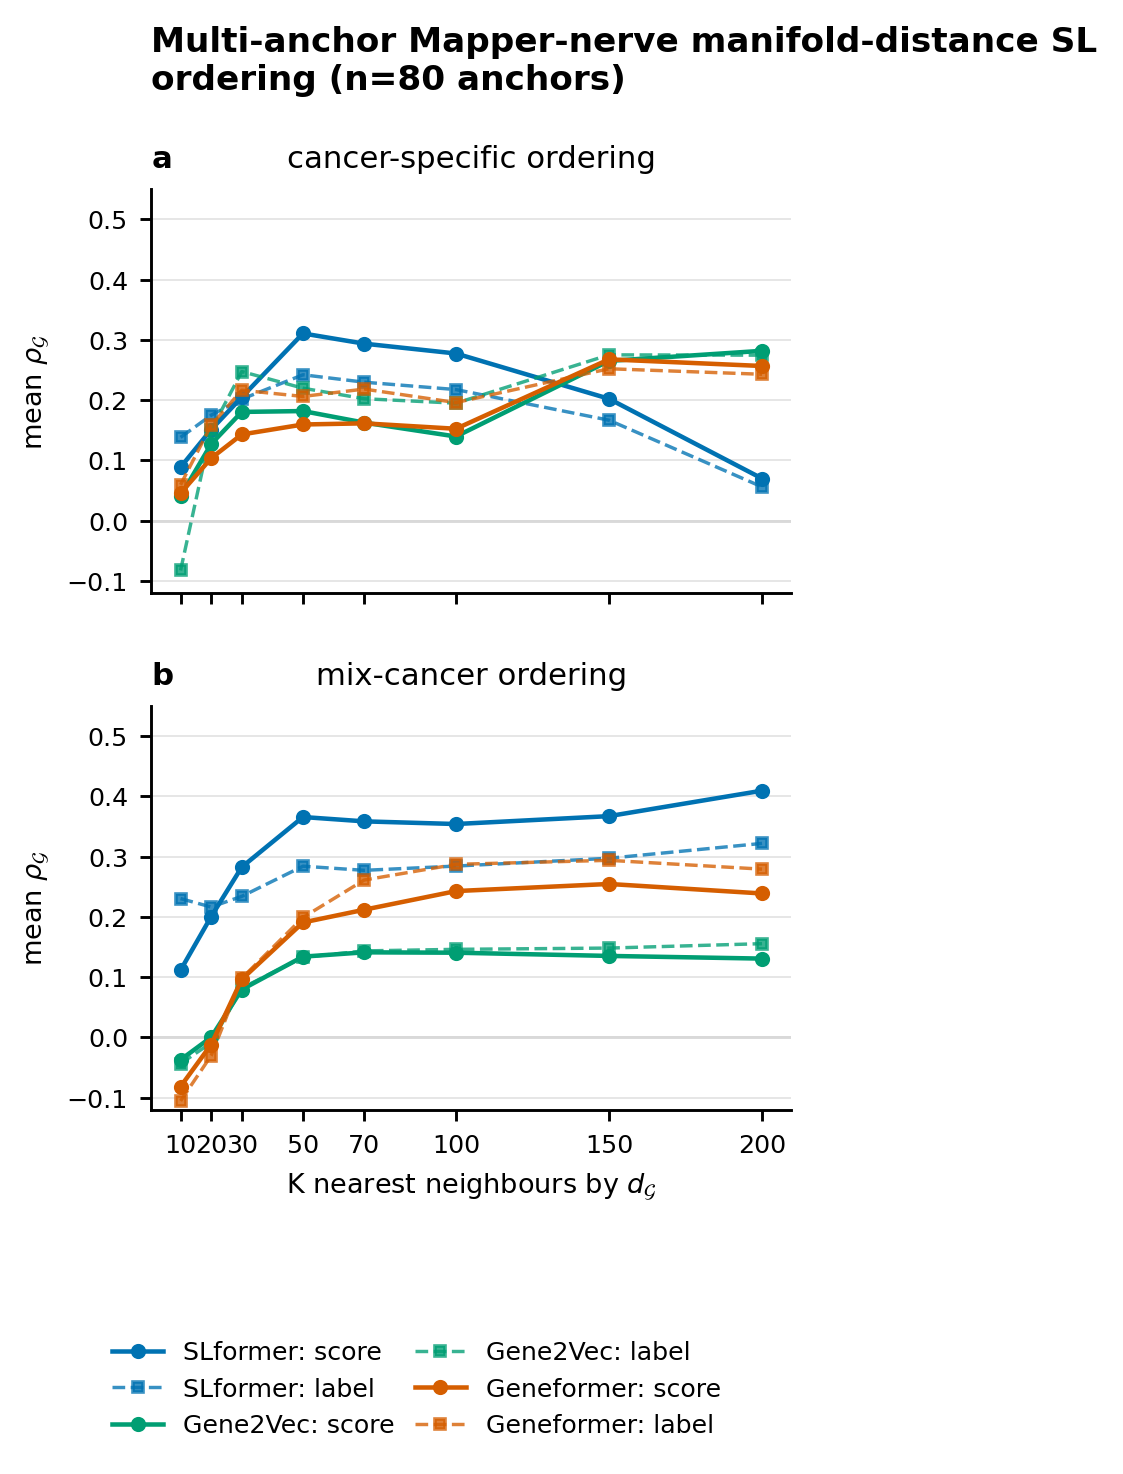

In [7]:

fig = plot_multi_anchor_manifold_ordering(
    multi_anchor_summary_mapper,
    anchor_count=len(multi_anchor_indices),
    ks=MANIFOLD_KS,
    distance_label=r"$d_{\mathcal{G}}$",
    rho_label=r"$\rho_{\mathcal{G}}$",
    title=f"Multi-anchor Mapper-nerve manifold-distance SL ordering (n={len(multi_anchor_indices)} anchors)",
    # out_path=PROJECT_ROOT / "output" / "SAE" / "figures" / "mapper_nerve_sl_ordering.svg",
)

mapper_table = compact_manifold_ordering_table(
    multi_anchor_summary_mapper,
    key_k=(10, 50, 100, 200),
    rho_label=r"$\rho_{\mathcal{G}}$",
)
